In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
df=pd.read_csv("./Housing.csv")
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [55]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [56]:
df=df.select_dtypes(include=['float64','int64'])
df

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2
...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2
541,1767150,2400,3,1,1,0
542,1750000,3620,2,1,1,0
543,1750000,2910,3,1,1,0


In [57]:
print(df.isnull().sum())

price        0
area         0
bedrooms     0
bathrooms    0
stories      0
parking      0
dtype: int64


<AxesSubplot: >

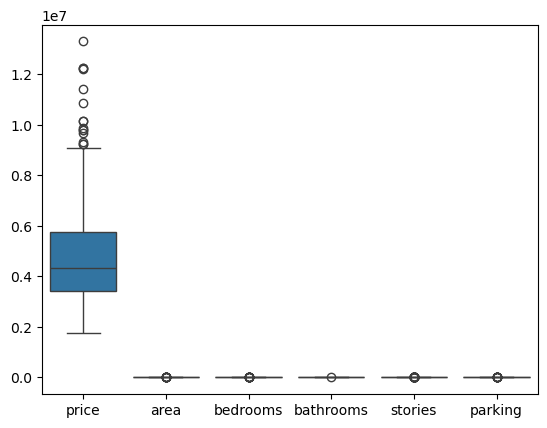

In [58]:
sns.boxplot(df)

In [59]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
df=pd.DataFrame(StandardScaler().fit_transform(df),columns=df.columns)
df

,price,area,bedrooms,bathrooms,stories,parking
0,4.566365,1.046726,1.403419,1.421812,1.378217,1.517692
1,4.004484,1.757010,1.403419,5.405809,2.532024,2.679409
2,4.004484,2.218232,0.047278,1.421812,0.224410,1.517692
3,3.985755,1.083624,1.403419,1.421812,0.224410,2.679409
4,3.554979,1.046726,1.403419,-0.570187,0.224410,1.517692
...,...,...,...,...,...,...
540,-1.576868,-0.991879,-1.308863,-0.570187,-0.929397,1.517692
541,-1.605149,-1.268613,0.047278,-0.570187,-0.929397,-0.805741
542,-1.614327,-0.705921,-1.308863,-0.570187,-0.929397,-0.805741
543,-1.614327,-1.033389,0.047278,-0.570187,-0.929397,-0.805741


<AxesSubplot: >

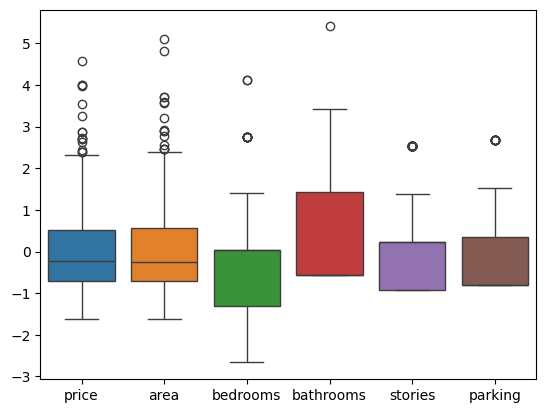

In [60]:
sns.boxplot(df)

In [61]:
def outlier_remover(a1,a2,b1,b2,c1,c2,d1,d2,df):
    new_df=df[(df['price']>a1)&(df['price']<a2)&(df['area']>b1)&(df['area']<b2)&(df['bathrooms']>c1)&(df['bathrooms']<c2)&(df['stories']>d1)&(df['stories']<d2)]
    return new_df

In [62]:
#range=[Q1−1.5⋅IQR,Q3+1.5⋅IQR]

q1=df[['price','area','bathrooms','stories']].quantile(0.25)
q3=df[['price','area','bathrooms','stories']].quantile(0.75)

price_a=q1.price-1.5*(q3.price-q1.price)
price_b=q3.price+1.5*(q3.price-q1.price)

area_a=q1.area-1.5*(q3.area-q1.area)
area_b=q3.area+1.5*(q3.area-q1.area)

bathrooms_a=q1.bathrooms-1.5*(q3.bathrooms-q1.bathrooms)
bathrooms_b=q3.bathrooms+1.5*(q3.bathrooms-q1.bathrooms)

stories_a=q1.stories-1.5*(q3.stories-q1.stories)
stories_b=q3.stories+1.5*(q3.stories-q1.stories)

df2=outlier_remover(price_a,price_b,area_a,area_b,bathrooms_a,bathrooms_b,stories_a,stories_b,df)
df2

,price,area,bedrooms,bathrooms,stories,parking
15,2.318841,0.391790,1.403419,-0.570187,0.224410,1.517692
16,2.318841,0.668524,1.403419,1.421812,0.224410,0.355976
18,2.206465,-0.253922,0.047278,1.421812,0.224410,1.517692
19,2.187735,0.585503,0.047278,1.421812,0.224410,0.355976
20,2.131547,-0.383065,0.047278,-0.570187,0.224410,1.517692
...,...,...,...,...,...,...
540,-1.576868,-0.991879,-1.308863,-0.570187,-0.929397,1.517692
541,-1.605149,-1.268613,0.047278,-0.570187,-0.929397,-0.805741
542,-1.614327,-0.705921,-1.308863,-0.570187,-0.929397,-0.805741
543,-1.614327,-1.033389,0.047278,-0.570187,-0.929397,-0.805741


<AxesSubplot: >

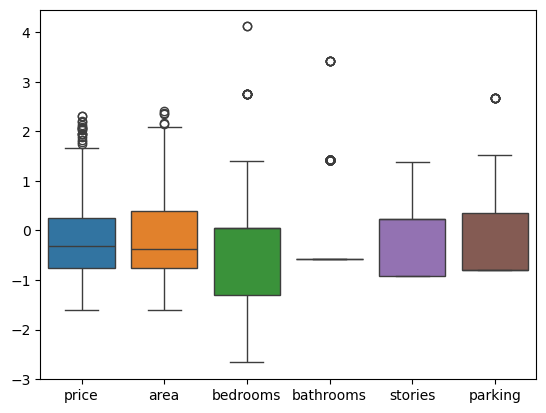

In [63]:
sns.boxplot(df2)

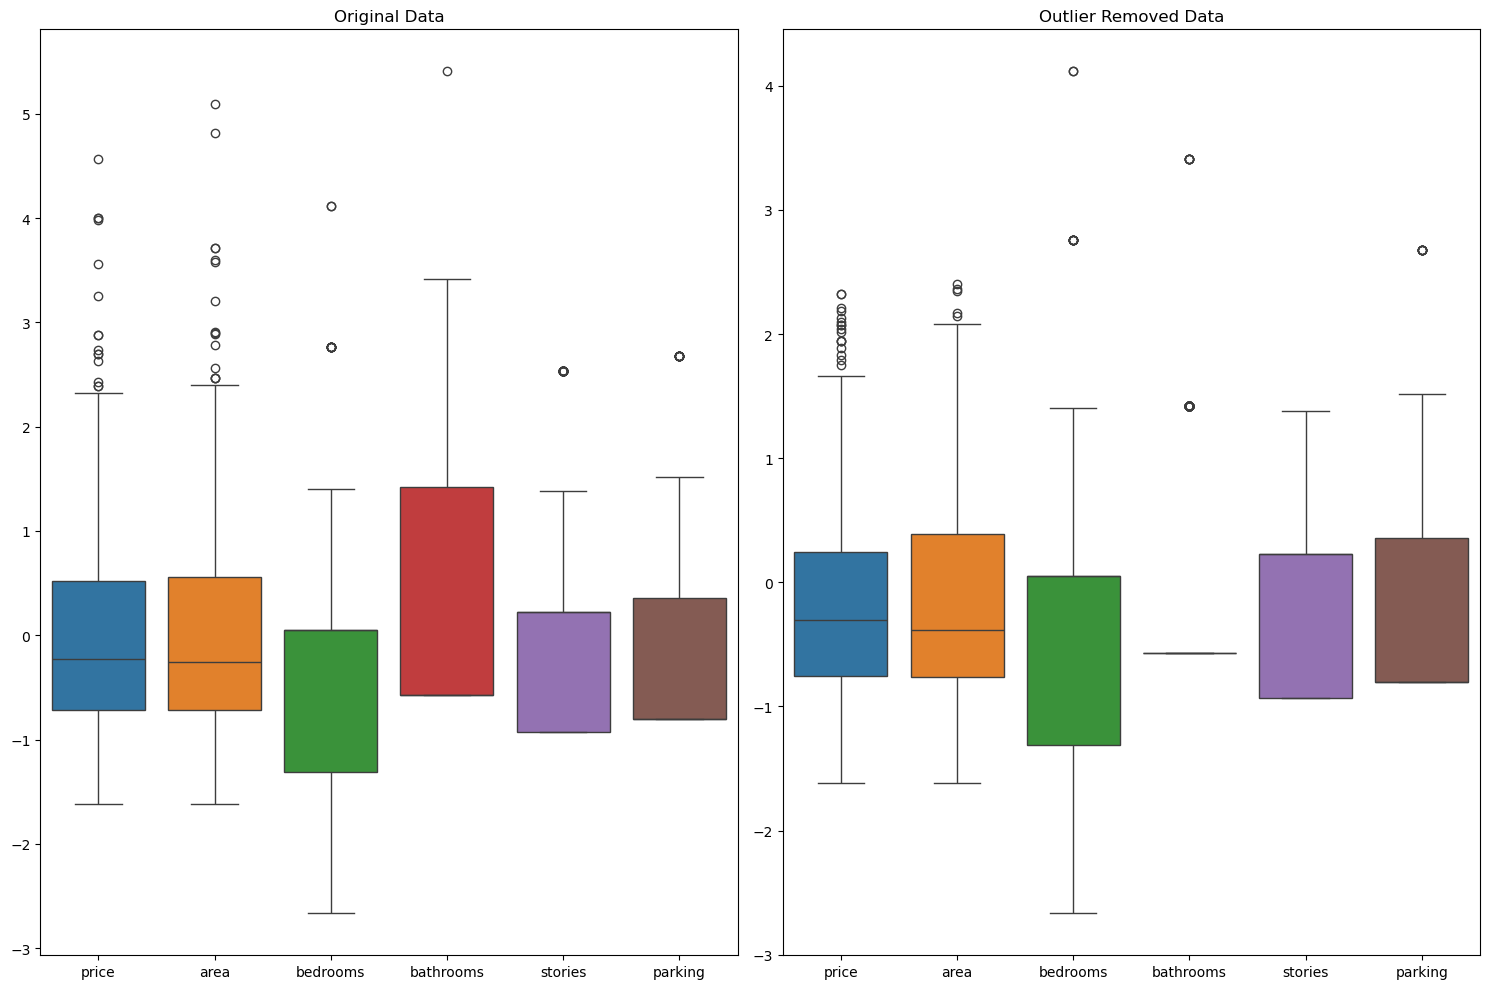

In [64]:
fig,axes = plt.subplots(1,2,figsize=(15, 10))

sns.boxplot(df,ax=axes[0])
axes[0].set_title("Original Data")

sns.boxplot(df2,ax=axes[1])
axes[1].set_title("Outlier Removed Data")

plt.tight_layout()
plt.show()

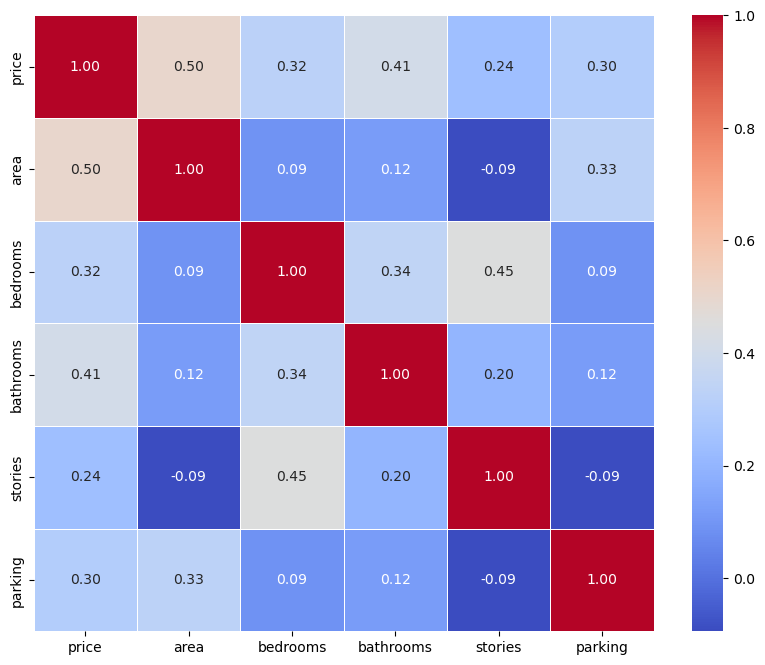

In [65]:
corr_matrix=df2.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

In [66]:
X=df2[['area','bathrooms','stories']].values
y=df2['price'].values

In [67]:
print('Feature matrix:\n',X.shape)

Feature matrix:
 (479, 3)


In [68]:
print('Target vector:\n',y.shape)

Target vector:
 (479,)


In [69]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size = 0.2)

In [70]:
intercept=np.ones((X_train.shape[0],1))
X_train = np.concatenate((intercept,X_train),axis=1)

intercept=np.ones((X_test.shape[0],1))
X_test=np.concatenate((intercept, X_test),axis=1)

In [71]:
from time import time

theta=np.zeros(X_train.shape[1])
alpha=0.001
max_iteration=50

start=time()

for i in range(max_iteration):
    y_hat=X_train@theta
    grad=X_train.T@(y_hat-y_train)
    theta=theta-alpha*grad
    
time_taken=time()-start

print("Time taken:",time_taken)
print("Theta:",theta)

Time taken: 0.0010247230529785156
Theta: [-0.04056304  0.47924421  0.26548089  0.22280519]


In [72]:
def mse(yhat, y):
   return  ((yhat - y)**2).sum() / yhat.shape[0]

In [73]:
yhat_train=X_train@theta
mse_train=mse(yhat_train,y_train)
print("MSE train:",mse_train)

yhat_test=X_test@theta
mse_test=mse(yhat_test,y_test)
print("MSE test:",mse_test)

MSE train: 0.3363925637495406
MSE test: 0.44792551737596886


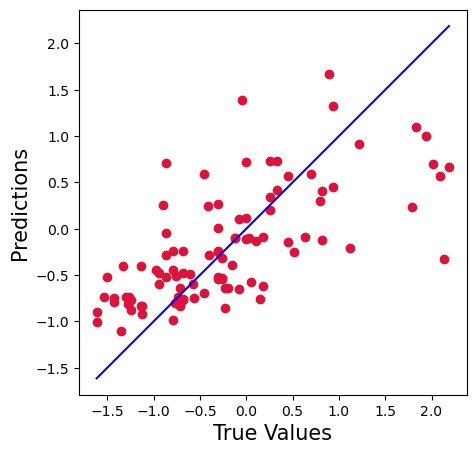

In [74]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, yhat_test,c='crimson')

p1=max(max(yhat_test),max(y_test))
p2=min(min(yhat_test), min(y_test))
plt.plot([p1,p2],[p1,p2],'b-')
plt.xlabel('True Values',fontsize=15)
plt.ylabel('Predictions',fontsize=15)
plt.axis('equal')
plt.show()

In [75]:
print('Sample value test -->',X_test[0]@theta)
print('predicted value -->',y_test[0])

Sample value test --> -0.4028819250371741
predicted value --> -1.3333862091245725
